<a href="https://colab.research.google.com/github/emissilva/challenge-clickbus/blob/main/scripts/analises/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv('/content/resultado_p1_2023.csv')
df

,fk_contact,recency,frequency,monetary,cluster
0,cliente_1,104,3,2011.76,6
1,cliente_100,2,28,1685.42,5
2,cliente_1000,80,2,672.91,0
3,cliente_100006,321,1,235.99,1
4,cliente_100009,83,1,57.88,0
...,...,...,...,...,...
149125,cliente_99982,353,1,414.79,1
149126,cliente_99991,45,1,243.42,0
149127,cliente_99992,72,1,113.66,0
149128,cliente_99996,93,1,42.18,0


In [5]:
zero_counts = df.eq(0).sum()
print(zero_counts)

fk_contact        0
recency           0
frequency         0
monetary          0
cluster       63388
dtype: int64


In [6]:
features = df[['recency', 'frequency', 'monetary']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [7]:
# Aplicar o PCA para reduzir as dimensões
# Reduz as features para 2 componentes principais
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# 4. Criar um novo DataFrame com os componentes
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# 5. Analisar o resultado
print("Dados originais:\n", df.head())
print("\nDados após o PCA:\n", pca_df.head())
print("\nVariância explicada por cada componente:")
print(pca.explained_variance_ratio_)

Dados originais:
        fk_contact  recency  frequency  monetary  cluster
0       cliente_1      104          3   2011.76        6
1     cliente_100        2         28   1685.42        5
2    cliente_1000       80          2    672.91        0
3  cliente_100006      321          1    235.99        1
4  cliente_100009       83          1     57.88        0

Dados após o PCA:
         PC1       PC2
0  1.157389 -0.002549
1  4.706262 -0.195397
2  0.205310 -0.496008
3 -0.714028  1.324661
4 -0.337693 -0.624941

Variância explicada por cada componente:
[0.60043824 0.3166397 ]


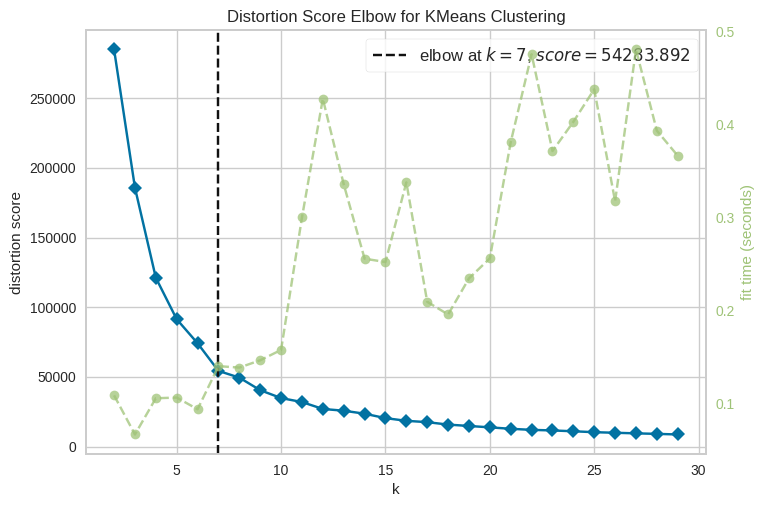

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [8]:
model = KMeans(random_state=42, n_init='auto')
visualizer_inertia = KElbowVisualizer(model, k=(2, 30), metric='distortion')
visualizer_inertia.fit(principal_components)
visualizer_inertia.show()

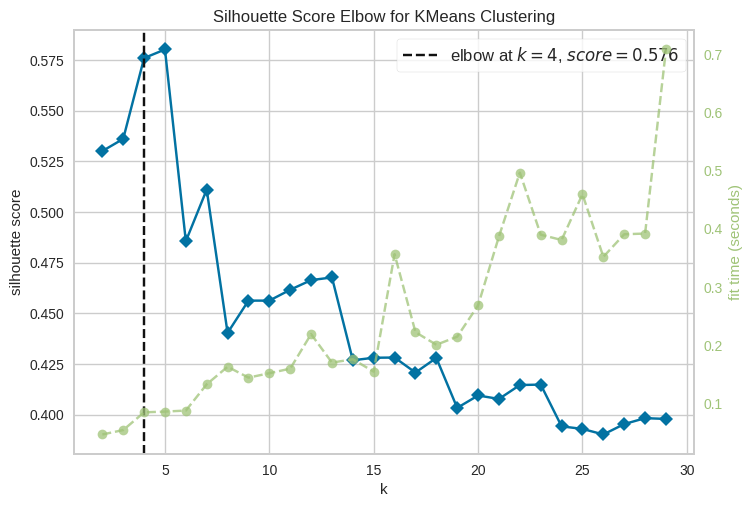

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [9]:
visualizer_silhouette = KElbowVisualizer(model, k=(2, 30), metric='silhouette')
visualizer_silhouette.fit(principal_components)
visualizer_silhouette.show()

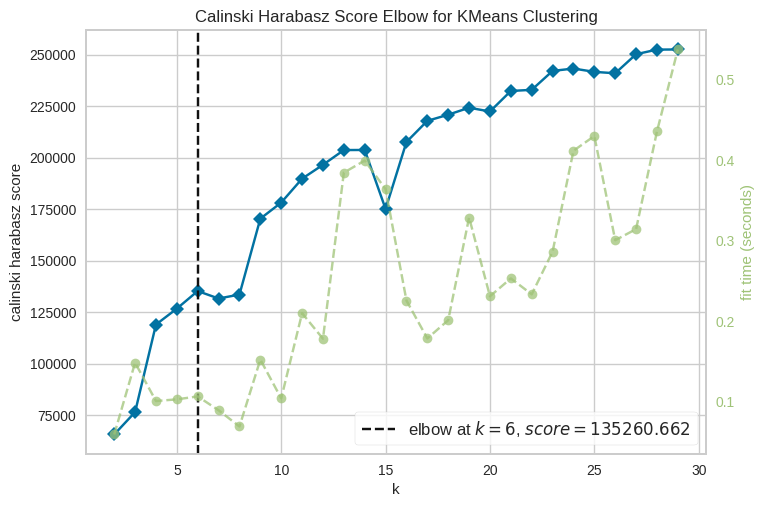

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [10]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,30),metric='calinski_harabasz', timings= True)
visualizer.fit(principal_components)
visualizer.show()

In [19]:
kmeans_final = KMeans(n_clusters=4)

In [20]:
kmeans_final.fit(principal_components)

KMeans(n_clusters=4)

In [21]:
cluster_pred = kmeans_final.predict(principal_components)

In [22]:
cluster_centers = kmeans_final.cluster_centers_

In [23]:
cluster_centers

array([[-1.81931694e-01,  2.17884517e-02],
       [ 4.75260945e-01, -8.27124474e-01],
       [-6.06044774e-01,  1.24740923e+00],
       [ 5.36110075e+01,  1.30907758e+01]])

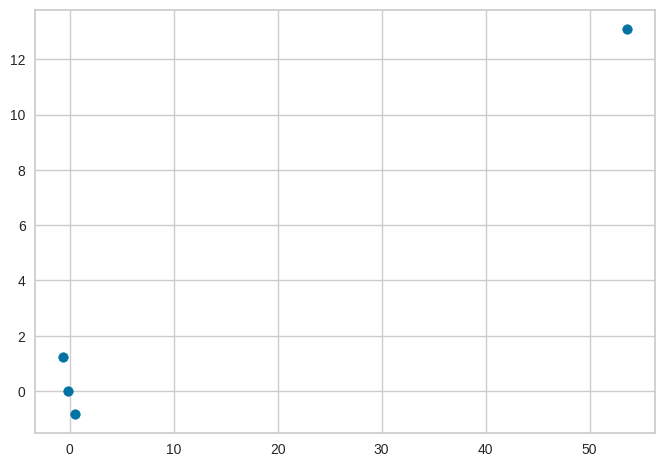

In [24]:
plt.scatter(cluster_centers[:,0], cluster_centers[:,1])
plt.show()

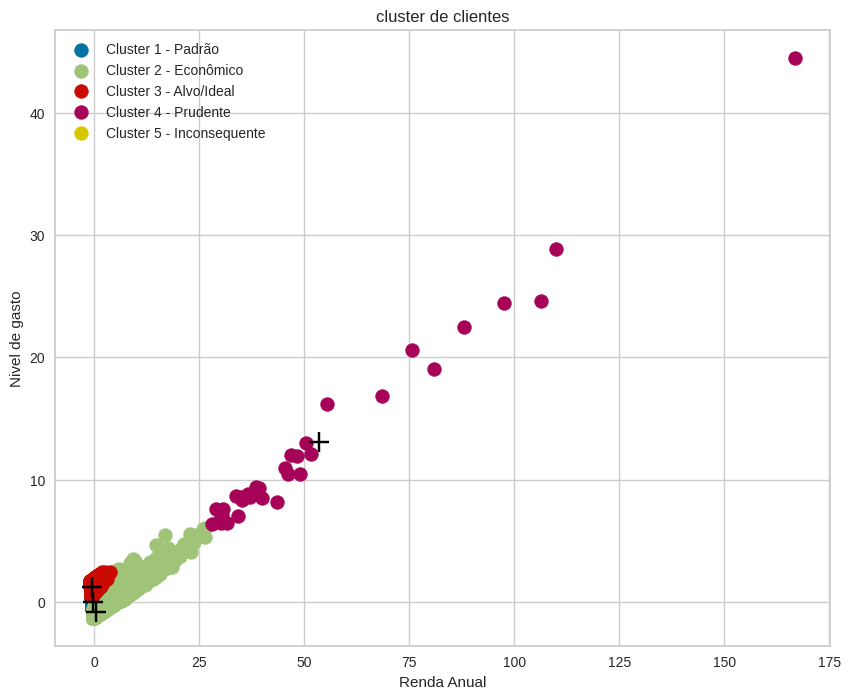

In [25]:
plt.figure(figsize=(10,8))
plt.scatter(principal_components[cluster_pred==0, 0], principal_components[cluster_pred==0, 1],s=100, label='Cluster 1 - Padrão')
plt.scatter(principal_components[cluster_pred==1, 0], principal_components[cluster_pred==1, 1],s=100, label='Cluster 2 - Econômico')
plt.scatter(principal_components[cluster_pred==2, 0], principal_components[cluster_pred==2, 1],s=100, label='Cluster 3 - Alvo/Ideal')
plt.scatter(principal_components[cluster_pred==3, 0], principal_components[cluster_pred==3, 1],s=100, label='Cluster 4 - Prudente')
plt.scatter(principal_components[cluster_pred==4, 0], principal_components[cluster_pred==4, 1],s=100, label='Cluster 5 - Inconsequente')
plt.scatter(cluster_centers[:,0],cluster_centers[:,1], marker='+', s=200, c='black')
plt.legend()
plt.title('cluster de clientes')
plt.xlabel('Renda Anual')
plt.ylabel('Nivel de gasto')
plt.show()